# 01 — LUNA16 data preparation

Build the unified patch dataset that powers every LUNA16 experiment in this project:
- positive nodules from `annotations.csv`
- negative candidates from `candidates_V2.csv` (subsampled per scan)
- 3D cubic patches for radiomics + 2D axial slices for ResNet50 + spherical ROI masks

Output goes to `results/luna16_cache/`. Reload with `np.load(...)` in downstream notebooks.

Datasets must be downloaded from https://luna16.grand-challenge.org and the path set in `configs/luna16.yaml`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import yaml

from utils.seed import set_seed
from utils.data_luna16 import (
    load_annotations,
    load_candidates,
    sample_balanced_negatives,
    build_patch_dataset,
)

with open('../configs/luna16.yaml') as f:
    cfg = yaml.safe_load(f)

set_seed(cfg['seed'])
cfg

{'seed': 42,
 'data': {'root': '../../data/luna16',
  'annotations_csv': '${data.root}/annotations.csv',
  'candidates_csv': '${data.root}/candidates_V2.csv',
  'subsets': ['subset0', 'subset1', 'subset2'],
  'cache_dir': '../results/luna16_cache'},
 'patches': {'patch_size_3d': 64,
  'patch_size_2d': 224,
  'hu_low': -1000,
  'hu_high': 400,
  'positive_per_scan': None,
  'negative_to_positive_ratio': 3.0,
  'roi_radius_vox': 4.0},
 'cv': {'n_splits': 5, 'inner_splits': 3, 'scoring': 'roc_auc'},
 'dl': {'batch_size': 32,
  'epochs': 50,
  'lr': 0.0001,
  'weight_decay': 0.0001,
  'patience': 7,
  'num_workers': 4,
  'device': 'cuda'},
 'paths': {'results': '../results', 'figures': '../results/figures'}}

In [2]:
data_root = Path(cfg['data']['root'])
annot = load_annotations(data_root / 'annotations.csv')
cand = load_candidates(data_root / 'candidates_V2.csv', only_negative=True)

print('positives:', len(annot))
print('negative candidates available:', len(cand))
annot.head()

positives: 1186
negative candidates available: 753418


,seriesuid,coordX,coordY,coordZ,diameter_mm,label
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471,1
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708,1
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348,1
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262,1
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150,1


In [3]:
ratio = cfg['patches'].get('negative_to_positive_ratio', 0.2)
n_pos_per_series = annot.groupby('seriesuid').size()
negatives = sample_balanced_negatives(cand, n_pos_per_series, ratio=ratio, seed=cfg['seed'])
print('sampled negatives:', len(negatives))
print('positive/negative ratio:', len(annot) / max(len(negatives), 1))

sampled negatives: 3558
positive/negative ratio: 0.3333333333333333


In [4]:
out_dir = Path('../') / cfg['data']['cache_dir']
labels_df = build_patch_dataset(
    annotations=annot,
    negatives=negatives,
    luna_root=data_root,
    subsets=cfg['data']['subsets'],
    out_dir=out_dir,
    patch_size_3d=cfg['patches']['patch_size_3d'],
    patch_size_2d=cfg['patches']['patch_size_2d'],
    hu_low=cfg['patches']['hu_low'],
    hu_high=cfg['patches']['hu_high'],
    roi_radius_vox=cfg['patches']['roi_radius_vox'],
)
labels_df['label'].value_counts()

[1/601] skip 1.3.6.1.4.1.14519.5.2.1.6279.6001.295462530340364058116953738925 (no .mhd)
[2/601] 1.3.6.1.4.1.14519.5.2.1.6279.6001.466284753932369813717081722101 → 4 candidates
[3/601] skip 1.3.6.1.4.1.14519.5.2.1.6279.6001.877026508860018521147620598474 (no .mhd)
[4/601] skip 1.3.6.1.4.1.14519.5.2.1.6279.6001.204802250386343794613980417281 (no .mhd)
[5/601] skip 1.3.6.1.4.1.14519.5.2.1.6279.6001.997611074084993415992563148335 (no .mhd)
[6/601] skip 1.3.6.1.4.1.14519.5.2.1.6279.6001.177685820605315926524514718990 (no .mhd)
[7/601] skip 1.3.6.1.4.1.14519.5.2.1.6279.6001.229096941293122177107846044795 (no .mhd)
[8/601] skip 1.3.6.1.4.1.14519.5.2.1.6279.6001.269075535958871753309238331179 (no .mhd)
[9/601] 1.3.6.1.4.1.14519.5.2.1.6279.6001.458525794434429386945463560826 → 4 candidates
[10/601] skip 1.3.6.1.4.1.14519.5.2.1.6279.6001.107351566259572521472765997306 (no .mhd)
[11/601] skip 1.3.6.1.4.1.14519.5.2.1.6279.6001.202283133206014258077705539227 (no .mhd)
[12/601] skip 1.3.6.1.4.1.1451

label
0    855
1    215
Name: count, dtype: int64

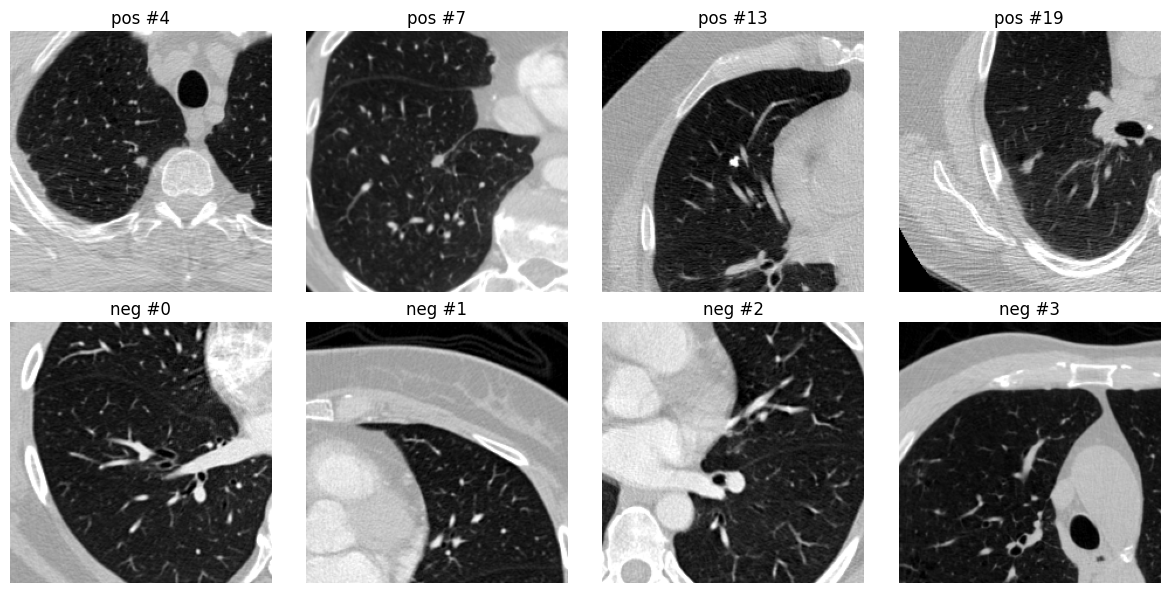

In [5]:
# Quick visual sanity check.
import numpy as np
import matplotlib.pyplot as plt

slices = np.load(out_dir / 'slices_2d.npy')
labels = labels_df['label'].to_numpy()

pos_idx = np.where(labels == 1)[0][:4]
neg_idx = np.where(labels == 0)[0][:4]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, idx in enumerate(pos_idx):
    axes[0, i].imshow(slices[idx], cmap='gray'); axes[0, i].set_title(f'pos #{idx}'); axes[0, i].axis('off')
for i, idx in enumerate(neg_idx):
    axes[1, i].imshow(slices[idx], cmap='gray'); axes[1, i].set_title(f'neg #{idx}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()